# 03 — Delta-area trajectory feature engineering

**Notebook 3 of 9 — Drosophila book-chapter production pipeline**

**Purpose:** Derive interpretable statistical, temporal, spectral, magnitude, complexity, and shape features from retained normalized delta-area trajectories.

**Primary inputs:** `data/processed/df_wide_delta.csv`; `data/processed/multi_level_combined_nonimputed_normalized.csv`

**Primary outputs:** `data/processed/delta_series.csv`; `data/processed/drosophila_features.csv`; `data/processed/drosophila_features_scaled.csv`; `data/processed/feature_dictionary.csv`

**Manuscript role:** Feature construction for PCA, NMF, correlation reduction, and consensus-group characterization.

**Project authors:** Tim Rogalsky, Nicolas Malagon, Lia Campbell-Enns, Matthaeus Dyck

**Reproducibility:** Designed for fresh-kernel execution in production order 01→09 using repository-relative paths. It consumes explicit normalized trajectory interfaces written by Notebook 01 and requires no private, diagnostic, or obsolete provenance artifact.

## Production feature workflow

Each input column is one normalized delta-area trajectory sampled at 20-minute intervals. After applying the accepted missingness threshold, the notebook preserves the deterministic order of 108 retained cells and calculates seven feature families:

- **Statistical summary features**: central tendency, spread, and shape of delta distributions.
- **Oscillation and frequency-domain features**: characteristics of signal periodicity and spectral content.
- **Peak and trough timing features**: timing and regularity of local extrema.
- **Magnitude change features**: trends in the amplitude of oscillations over time.
- **Complexity and autocorrelation features**: measures of signal irregularity and internal structure.
- **Early vs. late behavior features**: comparison of dynamics at the start and end of the time series.
- **Oscillation shape features**: sharpness and asymmetry of the signal waveform.

The resulting production matrices support correlation reduction, PCA, NMF, clustering, and downstream feature characterization.

#### Missingness and feature contract

- Category a ignores `NaN` values directly; temporal Categories b–g operate on each cell's finite observed span.
- The 108 retained trajectories contain no internal gaps. Missing heads and tails are excluded without filling, extrapolation, or a shifted time origin.
- The helper includes a generic linear-interpolation fallback for a genuine internal gap, but that branch is not used for the analyzed dataset.
- The executable workflow generates 56 feature columns. `energy` is not part of this candidate matrix, and `sample_entropy` is removed because it is non-finite for a substantial subset of cells, leaving 55 usable production features before correlation reduction.


## Production data

The Notebook-01 interfaces contain 131 normalized delta-area trajectories from three time-lapse movies with 39, 41, and 48 observations. The accepted 25% missingness threshold retains 108 trajectories. Features are calculated from each retained cell's observed span while preserving its original developmental-time coordinates.

#### Feature-engineering steps
1. Load the retained normalized delta data.
2. Apply the established missingness filter and preserve retained-cell order.
3. Calculate the seven accepted feature families from each observed delta span.
4. Validate the 56 generated columns, remove non-finite `sample_entropy`, and export the 55-feature unscaled, scaled, and dictionary outputs.


In [1]:
# Set the environment variable to avoid memory leak in KMeans
import os

# Set the environment variable 
os.environ['OMP_NUM_THREADS'] = '1'


In [2]:
# Install necessary libraries. 

# Uncomment next line if you don't have these installed
# !pip install tslearn 
# !pip install antropy





In [3]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
import warnings
import time
# from sklearn.base import BaseEstimator, TransformerMixin
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import MinMaxScaler
from tslearn.clustering import TimeSeriesKMeans
from scipy.cluster.hierarchy import linkage, dendrogram
from tslearn.metrics import cdist_dtw
from scipy.cluster.hierarchy import fcluster
from tslearn.barycenters import dtw_barycenter_averaging
from tslearn.metrics import cdist_dtw
from sklearn.mixture import GaussianMixture
from sklearn.cluster import DBSCAN


c:\venvs\drosophila-book\Lib\site-packages\tslearn\bases\bases.py:15: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


## 1. Load the data from csv
- Read the wide-format normalized delta file.
- Read the delta-only normalized MultiIndex file used to recover movie lengths.
- Convert the retained delta trajectories to a NumPy array.

#### CSV Files:
- **File Name**: `df_wide_delta.csv`
    - **Contents**: Contains the `df_wide_delta` DataFrame in CSV format, with each column representing the wide-format data for the normalized delta values. The rows correspond to the time points, and each column represents a unique cell identifier.
- **File Name**: `multi_level_combined_nonimputed_normalized.csv`
    - **Contents**: Contains the `multi_level_combined_nonimputed_normalized_df` DataFrame in CSV format, preserving the multi-level structure with 'Time (minutes)' as the index and 'Movie', 'Cell', and 'Trend' as levels. The sole trend is normalized `Delta`.


#### Multi-Level DataFrame Structure

**Name**: `multi_level_combined_nonimputed_normalized_df`

**Columns**: MultiIndex with levels:

- **Index**: 'Time (minutes)'
    - The primary index representing the time in 20-minute increments for each measurement.
- **Level 1**: 'Movie'
    - The movie identifier (e.g., 'Mov. 1', 'Mov. 2').
- **Level 2**: 'Cell'
    - The cell identifier (e.g., 'Cell 1', 'Cell 2') for individual cells within each movie.
- **Level 3**: 'Trend'
    - The type of measurement, currently normalized 'Delta' (change in area).
 
**Index**: 'Time (minutes)'
- The primary index representing the time in 20-minute increments for each measurement.
  
**Description**: This production interface stores the normalized delta-area trajectories with `Movie`, `Cell`, and `Trend` column levels and `Time (minutes)` as the row index.


In [4]:
# Load retained processed datasets using repository-relative paths
from pathlib import Path

PROCESSED_DIR = Path("data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

df_wide_delta = pd.read_csv(PROCESSED_DIR / "df_wide_delta.csv")
multi_level_combined_nonimputed_normalized_df = pd.read_csv(
    PROCESSED_DIR / "multi_level_combined_nonimputed_normalized.csv",
    header=[0, 1, 2], index_col=0
)

print("df_wide_delta:")
display(df_wide_delta.info())
display(df_wide_delta.head())


df_wide_delta:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Columns: 131 entries, Mov. 1 - Cell 1 to Mov. 3 - Cell 9
dtypes: float64(131)
memory usage: 49.3 KB


None

,Mov. 1 - Cell 1,Mov. 1 - Cell 10,Mov. 1 - Cell 10.1,Mov. 1 - Cell 11,Mov. 1 - Cell 11.1,Mov. 1 - Cell 12,Mov. 1 - Cell 12.1,Mov. 1 - Cell 13,Mov. 1 - Cell 13.1,Mov. 1 - Cell 14,...,Mov. 3 - Cell 53,Mov. 3 - Cell 54,Mov. 3 - Cell 55,Mov. 3 - Cell 56,Mov. 3 - Cell 57,Mov. 3 - Cell 58,Mov. 3 - Cell 6,Mov. 3 - Cell 7,Mov. 3 - Cell 8,Mov. 3 - Cell 9
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.593469,0.568741,0.591821,0.651166,0.558849,NaN,0.552255,0.642922,0.687435,0.547310
1,NaN,0.591864,0.603343,0.674849,0.603070,0.666380,0.602798,NaN,0.602526,NaN,...,0.603360,0.707216,0.466532,0.677544,0.634682,NaN,0.567093,0.539068,0.372565,0.565444
2,NaN,0.544448,0.650595,0.547833,0.656210,0.497030,0.661824,NaN,0.667438,NaN,...,0.471477,0.621494,0.585227,0.507746,0.539066,NaN,0.580280,0.662707,0.712163,0.608305
3,NaN,0.651136,0.527207,0.547833,0.521593,0.629121,0.515979,NaN,0.510365,NaN,...,0.626441,0.583577,0.603358,0.844042,0.603360,NaN,0.591819,0.555552,0.647869,0.623141
4,NaN,0.581705,0.642916,0.563076,0.648779,0.576625,0.654643,NaN,0.660506,NaN,...,0.519285,0.590171,0.639627,0.529177,0.389051,NaN,0.726999,0.535769,0.494557,0.535771


## 2. Prepare the data

- Calculate the number of time steps per movie.
- Set a boolean flag (`truncate_series`) to truncate all time series to the shortest length.
- Set a threshold (`nan_threshold`, a relative frequency) to filter out time series with excessive NaN values.
- Clean the delta DataFrame and convert it to a NumPy array (`delta_series`) for feature analysis.
- Create `delta_identifier_map` to track original cell identifiers.

In [5]:
# Initialize a dictionary to store the number of time steps for each movie
movie_time_steps = {}

# Loop over each movie in the DataFrame
for movie in multi_level_combined_nonimputed_normalized_df.columns.get_level_values('Movie').unique():
    # Extract the DataFrame for the current movie and the 'Delta' columns
    movie_df = multi_level_combined_nonimputed_normalized_df.xs(movie, level='Movie', axis=1)
    delta_df = movie_df.xs('Delta', level='Trend', axis=1)
    
    # Initialize a list to store the last valid time index for each column
    last_valid_indices = []

    # Loop over each column in the delta DataFrame
    for col in delta_df.columns:
        # Find the last non-NaN value in the column
        last_valid_index = delta_df[col].last_valid_index()
        if last_valid_index is not None:
            last_valid_indices.append(last_valid_index)
    
    # Determine the time steps by dividing the max time index by 20
    if last_valid_indices:
        movie_length = max(last_valid_indices) // 20 + 1  # Add 1 to convert from index to steps
        movie_time_steps[movie] = movie_length

# Determine the minimum number of time steps across all movies
min_time_steps = min(movie_time_steps.values())

# Print the lengths of each movie and the minimum time steps
print(f"Number of time steps for each movie: {movie_time_steps}")
print(f"The minimum number of time steps across all movies is: {min_time_steps}")


Number of time steps for each movie: {'Mov. 1': np.int64(39), 'Mov. 2': np.int64(41), 'Mov. 3': np.int64(48)}
The minimum number of time steps across all movies is: 39


In [6]:
# Boolean flag to truncate all time series to the shortest length
truncate_series = False

# Set a threshold for the maximum percentage of NaNs allowed
nan_threshold = 0.25

# Make a copy of the DataFrame to avoid changing the original
df_wide_delta_copy = df_wide_delta.copy()

# Convert NaN values to np.nan format if not already and ensure no deprecated warning
df_wide_delta_copy = df_wide_delta_copy.apply(lambda x: np.where(pd.isna(x), np.nan, x))

# Truncate all series to the shortest length if truncate_series is True
if truncate_series:
    df_wide_delta_copy = df_wide_delta_copy.iloc[:min_time_steps, :]
    print(f"Note: All series have been truncated to {min_time_steps} time steps")

# Identify and filter out time series with more than the allowed percentage of NaNs
valid_delta_indices = (df_wide_delta_copy.isna().mean(axis=0) <= nan_threshold)

print(f"Columns with NaNs above threshold in delta_series: {(~valid_delta_indices).sum()}")

df_wide_delta_copy = df_wide_delta_copy.loc[:, valid_delta_indices]

# Re-create the identifier map after filtering
delta_identifier_map = {cell: idx for idx, cell in enumerate(df_wide_delta_copy.columns)}

# Convert the DataFrame to a numpy array
delta_series = df_wide_delta_copy.T.to_numpy()


Columns with NaNs above threshold in delta_series: 23


In [7]:
# Save the derived trajectory array with the other processed analysis outputs
np.savetxt(PROCESSED_DIR / "delta_series.csv", delta_series, delimiter=",", fmt="%f")
print(f"Delta trajectory array written to {PROCESSED_DIR}.")


Delta trajectory array written to data\processed.


## 3. Feature Engineering

### a. Statistical Summary Features (`df_stat_summary`)

These features describe the overall distribution and shape of the **normalized to [0,1]** delta time series for each cell, without reference to time order or oscillatory structure. They are stored in a dataframe named `df_stat_summary`.

These features summarize the location, spread, and shape of each globally normalized delta distribution. Because global min-max normalization does not preserve original zero as normalized zero, these transformed summaries do not by themselves establish biological growth or shrinkage.

| Variable Name       | Feature                            | Description |
|---------------------|-------------------------------------|-------------|
| `mean`              | Mean of delta                      | Average of all non-NaN delta values |
| `std`               | Standard deviation                 | Variability of delta values |
| `range`             | Range                              | Difference between max and min delta values |
| `median`            | Median                             | Middle value of the delta distribution |
| `skew`              | Skewness                           | Asymmetry of the delta distribution |
| `kurtosis`          | Kurtosis                           | Peakedness or tail heaviness of the delta distribution |

These descriptors support comparisons of relative level, variability, and distributional shape within the normalized production data.

In [8]:
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis

# Initialize list to hold each cell's features
stat_summary_features = []

# Loop through each cell's delta time series
for series in delta_series:
    # Remove NaNs for feature calculation
    valid_values = series[~np.isnan(series)]

    # Compute statistical features
    features = {
        'mean': np.mean(valid_values),
        'std': np.std(valid_values),
        'range': np.ptp(valid_values),
        'median': np.median(valid_values),
        'skew': skew(valid_values),
        'kurtosis': kurtosis(valid_values)
    }

    stat_summary_features.append(features)

# Convert to DataFrame
df_stat_summary = pd.DataFrame(stat_summary_features)

# Label the rows with the Drosophila cell identifiers
df_stat_summary.index = df_wide_delta_copy.columns

# Display structure and preview
display(df_stat_summary.info())
display(df_stat_summary.head())


<class 'pandas.core.frame.DataFrame'>
Index: 108 entries, Mov. 1 - Cell 10 to Mov. 3 - Cell 9
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   mean      108 non-null    float64
 1   std       108 non-null    float64
 2   range     108 non-null    float64
 3   median    108 non-null    float64
 4   skew      108 non-null    float64
 5   kurtosis  108 non-null    float64
dtypes: float64(6)
memory usage: 5.9+ KB


None

,mean,std,range,median,skew,kurtosis
Mov. 1 - Cell 10,0.587676,0.023740,0.121932,0.588479,0.091052,1.233599
Mov. 1 - Cell 10.1,0.592527,0.031883,0.166268,0.586206,0.737495,1.382178
Mov. 1 - Cell 11,0.589191,0.025852,0.127016,0.586784,0.951941,1.490865
Mov. 1 - Cell 11.1,0.593495,0.045360,0.265879,0.586087,1.112811,3.386564
Mov. 1 - Cell 12,0.589701,0.027997,0.169350,0.593559,-0.412399,2.607295


In [9]:
def prepare_observed_span(series):
    """Return finite values over a series' observed span and original coordinates.

    Leading and trailing NaNs are excluded, never filled. NaNs strictly between the
    first and last finite observations are linearly interpolated on the original
    index coordinates. The time origin is not shifted.
    """
    values = np.asarray(series, dtype=float)
    coordinates = np.arange(values.size, dtype=float)
    finite = np.isfinite(values)
    if not finite.any():
        return np.array([], dtype=float), np.array([], dtype=float)

    first, last = np.flatnonzero(finite)[[0, -1]]
    span_values = values[first:last + 1].copy()
    span_coordinates = coordinates[first:last + 1]
    span_finite = np.isfinite(span_values)
    if not span_finite.all():
        span_values[~span_finite] = np.interp(
            span_coordinates[~span_finite],
            span_coordinates[span_finite],
            span_values[span_finite]
        )
    return span_values, span_coordinates

def missingness_profile(series):
    values = np.asarray(series, dtype=float)
    finite = np.isfinite(values)
    if not finite.any():
        return True, True, 0
    first, last = np.flatnonzero(finite)[[0, -1]]
    return first > 0, last < len(values) - 1, int(np.isnan(values[first:last + 1]).sum())

profiles = [missingness_profile(series) for series in delta_series]
n_leading = sum(p[0] for p in profiles)
n_trailing = sum(p[1] for p in profiles)
n_internal_cells = sum(p[2] > 0 for p in profiles)

print("Cell order matches:", (df_stat_summary.index == df_wide_delta_copy.columns).all())
print(f"Retained cells processed: {len(delta_series)}")
print(f"Cells with leading NaNs: {n_leading}")
print(f"Cells with trailing NaNs: {n_trailing}")
print(f"Cells with internal NaNs: {n_internal_cells}")


Cell order matches: True
Retained cells processed: 108
Cells with leading NaNs: 31
Cells with trailing NaNs: 58
Cells with internal NaNs: 0


### b. Frequency-Domain Features (`df_oscillation_features`)

Periodograms are calculated on each cell's observed span at 3 observations/hour. Frequencies are therefore in **cycles/hour**. Total and band power are integrated over frequency-bin width. `spectral_entropy` is normalized by the log of the spectrum length for comparison across variable-length spectra. Missing heads/tails are excluded; only genuine internal gaps may be interpolated.


In [10]:
import numpy as np
import pandas as pd
from scipy.stats import entropy
from scipy.signal import periodogram

sampling_rate = 3  # observations/hour; periodogram frequencies are cycles/hour
low_band = (0, 0.05)
mid_band = (0.05, 0.15)
high_band = (0.15, 0.5)

oscillation_features = []
for series in delta_series:
    observed, observed_time = prepare_observed_span(series)
    if len(observed) < 3:
        oscillation_features.append({name: np.nan for name in [
            'dominant_freq', 'total_power', 'band_power_low', 'band_power_mid',
            'band_power_high', 'spectral_entropy', 'spectral_flatness']})
        continue

    freqs, power = periodogram(observed, fs=sampling_rate)
    dfreq = freqs[1] - freqs[0]
    power_sum = np.sum(power)
    if power_sum > 0:
        power_norm = power / power_sum
        spectral_entropy = entropy(power_norm) / np.log(len(power_norm)) if len(power_norm) > 1 else 0.0
    else:
        power_norm = np.zeros_like(power)
        spectral_entropy = 0.0

    with np.errstate(divide='ignore', invalid='ignore'):
        spectral_flatness = np.exp(np.mean(np.log(power + 1e-10))) / (np.mean(power) + 1e-10)

    def integrated_band_power(fmin, fmax):
        mask = (freqs >= fmin) & (freqs < fmax)
        return np.sum(power[mask]) * dfreq

    oscillation_features.append({
        'dominant_freq': freqs[np.argmax(power)],
        'total_power': np.sum(power) * dfreq,
        'band_power_low': integrated_band_power(*low_band),
        'band_power_mid': integrated_band_power(*mid_band),
        'band_power_high': integrated_band_power(*high_band),
        'spectral_entropy': spectral_entropy,
        'spectral_flatness': spectral_flatness
    })

df_oscillation_features = pd.DataFrame(oscillation_features, index=df_wide_delta_copy.columns)
display(df_oscillation_features.info())
display(df_oscillation_features.head())


<class 'pandas.core.frame.DataFrame'>
Index: 108 entries, Mov. 1 - Cell 10 to Mov. 3 - Cell 9
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   dominant_freq      108 non-null    float64
 1   total_power        108 non-null    float64
 2   band_power_low     108 non-null    float64
 3   band_power_mid     108 non-null    float64
 4   band_power_high    108 non-null    float64
 5   spectral_entropy   108 non-null    float64
 6   spectral_flatness  108 non-null    float64
dtypes: float64(7)
memory usage: 6.8+ KB


None

,dominant_freq,total_power,band_power_low,band_power_mid,band_power_high,spectral_entropy,spectral_flatness
Mov. 1 - Cell 10,1.026316,0.000564,6.914142e-34,1.102492e-07,0.000111,0.812080,0.237712
Mov. 1 - Cell 10.1,0.631579,0.001017,1.442580e-33,4.274636e-06,0.000241,0.868978,0.269014
Mov. 1 - Cell 11,0.789474,0.000668,8.740841e-33,2.991022e-06,0.000130,0.853356,0.279228
Mov. 1 - Cell 11.1,1.263158,0.002057,5.334986e-35,1.947201e-05,0.000184,0.831289,0.276946
Mov. 1 - Cell 12,1.500000,0.000784,5.252320e-33,4.604827e-06,0.000038,0.721673,0.164318


### c. Peak and Trough Timing Features (`df_peak_timing_features`)

These features describe the timing, frequency, and directional asymmetry of oscillatory events (peaks and troughs) in the delta time series. They are stored in a dataframe named `df_peak_timing_features`.

| Variable Name               | Feature                           | Description |
|-----------------------------|------------------------------------|-------------|
| `avg_time_between_peaks`    | Average time between peaks         | Mean number of time steps between consecutive local maxima |
| `std_time_between_peaks`    | Std dev of time between peaks      | Variation in the spacing of consecutive local maxima |
| `avg_time_between_troughs`  | Average time between troughs       | Mean number of time steps between consecutive local minima |
| `std_time_between_troughs`  | Std dev of time between troughs    | Variation in the spacing of consecutive local minima |
| `mean_peak_to_trough_time`  | Mean fall time                     | Average number of time steps it takes for the signal to fall from a peak to the next trough |
| `mean_trough_to_peak_time`  | Mean rise time                     | Average number of time steps it takes to rise from a trough to the next peak |
| `oscillation_rate`          | Oscillation rate                   | Total number of peaks and troughs per valid time step; reflects oscillatory density |

These features help quantify the regularity, speed, and symmetry of oscillatory activity during cell development.


Temporal features in Categories b–g are computed on each cell's observed span. The current 108 retained trajectories contain no internal gaps, so no analyzed value is interpolated. Missing heads and tails are excluded without filling or extrapolation, and the original padded-series coordinates preserve developmental-time position. The generic helper fallback for a future internal gap remains documented but unused here.


In [11]:
import numpy as np
import pandas as pd
from scipy.signal import find_peaks

peak_timing_features = []
window_length = 3
polyorder = 2

for series in delta_series:
    observed, observed_time = prepare_observed_span(series)
    if len(observed) < window_length:
        peak_timing_features.append({name: np.nan for name in [
            'avg_time_between_peaks', 'std_time_between_peaks',
            'avg_time_between_troughs', 'std_time_between_troughs',
            'mean_peak_to_trough_time', 'mean_trough_to_peak_time', 'oscillation_rate']})
        continue

    peaks, _ = find_peaks(observed)
    troughs, _ = find_peaks(-observed)
    oscillation_rate = (len(peaks) + len(troughs)) / len(observed)

    def timing_stats(indices):
        if len(indices) < 2:
            return np.nan, np.nan
        diffs = np.diff(observed_time[indices])
        return np.mean(diffs), np.std(diffs)

    avg_peak_time, std_peak_time = timing_stats(peaks)
    avg_trough_time, std_trough_time = timing_stats(troughs)
    extrema = sorted([(i, 'peak') for i in peaks] + [(i, 'trough') for i in troughs])
    pt_durations, tp_durations = [], []
    for (idx1, type1), (idx2, type2) in zip(extrema, extrema[1:]):
        duration = observed_time[idx2] - observed_time[idx1]
        if type1 == 'peak' and type2 == 'trough':
            pt_durations.append(duration)
        elif type1 == 'trough' and type2 == 'peak':
            tp_durations.append(duration)

    peak_timing_features.append({
        'avg_time_between_peaks': avg_peak_time,
        'std_time_between_peaks': std_peak_time,
        'avg_time_between_troughs': avg_trough_time,
        'std_time_between_troughs': std_trough_time,
        'mean_peak_to_trough_time': np.mean(pt_durations) if pt_durations else np.nan,
        'mean_trough_to_peak_time': np.mean(tp_durations) if tp_durations else np.nan,
        'oscillation_rate': oscillation_rate
    })

df_peak_timing_features = pd.DataFrame(peak_timing_features, index=df_wide_delta_copy.columns)
display(df_peak_timing_features.info())
display(df_peak_timing_features.head())


<class 'pandas.core.frame.DataFrame'>
Index: 108 entries, Mov. 1 - Cell 10 to Mov. 3 - Cell 9
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   avg_time_between_peaks    108 non-null    float64
 1   std_time_between_peaks    108 non-null    float64
 2   avg_time_between_troughs  108 non-null    float64
 3   std_time_between_troughs  108 non-null    float64
 4   mean_peak_to_trough_time  108 non-null    float64
 5   mean_trough_to_peak_time  108 non-null    float64
 6   oscillation_rate          108 non-null    float64
dtypes: float64(7)
memory usage: 6.8+ KB


None

,avg_time_between_peaks,std_time_between_peaks,avg_time_between_troughs,std_time_between_troughs,mean_peak_to_trough_time,mean_trough_to_peak_time,oscillation_rate
Mov. 1 - Cell 10,2.909091,0.899954,2.916667,0.640095,1.500000,1.416667,0.657895
Mov. 1 - Cell 10.1,3.090909,1.564059,3.200000,1.536229,1.727273,1.363636,0.605263
Mov. 1 - Cell 11,2.727273,0.862439,2.750000,0.829156,1.416667,1.333333,0.657895
Mov. 1 - Cell 11.1,2.916667,1.440968,3.000000,1.477098,1.500000,1.416667,0.657895
Mov. 1 - Cell 12,2.461538,0.745797,2.461538,0.634324,1.384615,1.071429,0.777778


### d. Magnitude Change Features (`df_magnitude_features`)

These features quantify the strength, direction, and variability of oscillations over time by analyzing the amplitude between peaks and troughs in the delta time series. They are stored in a dataframe named `df_magnitude_features`.

Rather than focusing on when oscillations occur, this feature set examines **how large** those oscillations are, how they **change over time**, and whether there are systematic differences between **falling** (peak-to-trough) and **rising** (trough-to-peak) phases. This is useful for identifying cells with increasing or decreasing oscillation strength, consistent vs. variable amplitude, and asymmetric developmental dynamics.

| Variable Name                          | Feature                                  | Description |
|----------------------------------------|-------------------------------------------|-------------|
| `slope_magnitude`                      | Slope of oscillation magnitude            | Linear trend of amplitude across all oscillations (positive = increasing strength over time) |
| `poly_mag_c0`, `c1`, `c2`, 'c3'        | Polynomial fit to magnitude               | Coefficients from a 3rd-order polynomial fit to the sequence of oscillation magnitudes |
| `poly_peak_c0`, `c1`, `c2`, 'c3'       | Polynomial fit to peak magnitude          | Coefficients from a 3rd-order polynomial fit to the sequence of peaks |
| `poly_trough_c0`, `c1`, `c2`, 'c3'     | Polynomial fit to trough magnitude        | Coefficients from a 3rd-order polynomial fit to the sequence of troughs |
| `mean_magnitude`                       | Mean amplitude                            | Mean peak-to-trough or trough-to-peak magnitude across all oscillations |
| `std_magnitude`                        | Std dev of amplitude                      | Variability in oscillation amplitude over time |
| `initial_magnitude`                   | Initial oscillation strength              | Average magnitude from the first 2–3 oscillations |
| `final_magnitude`                     | Final oscillation strength                | Average magnitude from the last 2–3 oscillations |
| `mean_peak_to_trough_magnitude`        | Mean fall amplitude                       | Average magnitude from peak to subsequent trough |
| `mean_trough_to_peak_magnitude`        | Mean rise amplitude                       | Average magnitude from trough to subsequent peak |
| `initial_peak_to_trough_magnitude`     | Initial fall amplitude                    | Average fall magnitude in the first 2–3 cycles |
| `final_peak_to_trough_magnitude`       | Final fall amplitude                      | Average fall magnitude in the last 2–3 cycles |
| `initial_trough_to_peak_magnitude`     | Initial rise amplitude                    | Average rise magnitude in the first 2–3 cycles |
| `final_trough_to_peak_magnitude`       | Final rise amplitude                      | Average rise magnitude in the last 2–3 cycles |

These features help capture how strongly and consistently each cell fluctuates, whether oscillation strength increases or decreases, and whether there's asymmetry between contraction and expansion phases during development.



Magnitude formulas are preserved from the final cubic implementation. Peak, trough, midpoint, polynomial, and linear-regression coordinates use the original padded-series index coordinates; trimming does not reset the time origin.


#### Historical degree-2 polynomial envelope (non-executing)

The superseded degree-2 implementation has been removed from the production execution path. The cubic implementation below is the sole production magnitude calculation.


Historical note: the earlier degree-2 envelope was inadequate and no longer executes.


#### degree 3 polynomial envelope (current)

In [12]:
import numpy as np
import pandas as pd
from scipy.signal import find_peaks
from numpy.polynomial.polynomial import polyfit

magnitude_features = []
feature_names = [
    'slope_magnitude', 'poly_mag_c0', 'poly_mag_c1', 'poly_mag_c2', 'poly_mag_c3',
    'poly_peak_c0', 'poly_peak_c1', 'poly_peak_c2', 'poly_peak_c3',
    'poly_trough_c0', 'poly_trough_c1', 'poly_trough_c2', 'poly_trough_c3',
    'mean_magnitude', 'std_magnitude', 'initial_magnitude', 'final_magnitude',
    'mean_peak_to_trough_magnitude', 'mean_trough_to_peak_magnitude',
    'initial_peak_to_trough_magnitude', 'final_peak_to_trough_magnitude',
    'initial_trough_to_peak_magnitude', 'final_trough_to_peak_magnitude']

for series in delta_series:
    observed, observed_time = prepare_observed_span(series)
    if len(observed) < 5:
        magnitude_features.append({name: np.nan for name in feature_names})
        continue

    peaks, _ = find_peaks(observed)
    troughs, _ = find_peaks(-observed)
    extrema = sorted([(i, 'peak') for i in peaks] + [(i, 'trough') for i in troughs])
    pt_magnitudes, tp_magnitudes, all_magnitudes, all_midpoints = [], [], [], []

    for (idx1, type1), (idx2, type2) in zip(extrema, extrema[1:]):
        midpoint = (observed_time[idx1] + observed_time[idx2]) / 2
        if type1 == 'peak' and type2 == 'trough':
            magnitude = observed[idx1] - observed[idx2]
            pt_magnitudes.append(magnitude)
            all_magnitudes.append(magnitude)
            all_midpoints.append(midpoint)
        elif type1 == 'trough' and type2 == 'peak':
            magnitude = observed[idx2] - observed[idx1]
            tp_magnitudes.append(magnitude)
            all_magnitudes.append(magnitude)
            all_midpoints.append(midpoint)

    def safe_polyfit(x, y):
        return polyfit(x, y, 3) if len(x) >= 5 else [np.nan] * 4

    coeffs_mag = safe_polyfit(all_midpoints, all_magnitudes)
    coeffs_peak = safe_polyfit(observed_time[peaks], observed[peaks])
    coeffs_trough = safe_polyfit(observed_time[troughs], observed[troughs])

    if len(all_magnitudes) >= 2:
        slope = np.polyfit(all_midpoints, all_magnitudes, 1)[0]
        mean_mag, std_mag = np.mean(all_magnitudes), np.std(all_magnitudes)
        initial_mag = np.mean(all_magnitudes[:3]) if len(all_magnitudes) >= 3 else mean_mag
        final_mag = np.mean(all_magnitudes[-3:]) if len(all_magnitudes) >= 3 else mean_mag
    else:
        slope = mean_mag = std_mag = initial_mag = final_mag = np.nan

    def directional_stats(mags):
        if not mags:
            return np.nan, np.nan
        return (np.mean(mags[:3]) if len(mags) >= 3 else np.mean(mags),
                np.mean(mags[-3:]) if len(mags) >= 3 else np.mean(mags))

    initial_pt, final_pt = directional_stats(pt_magnitudes)
    initial_tp, final_tp = directional_stats(tp_magnitudes)
    magnitude_features.append({
        'slope_magnitude': slope,
        'poly_mag_c0': coeffs_mag[0], 'poly_mag_c1': coeffs_mag[1], 'poly_mag_c2': coeffs_mag[2], 'poly_mag_c3': coeffs_mag[3],
        'poly_peak_c0': coeffs_peak[0], 'poly_peak_c1': coeffs_peak[1], 'poly_peak_c2': coeffs_peak[2], 'poly_peak_c3': coeffs_peak[3],
        'poly_trough_c0': coeffs_trough[0], 'poly_trough_c1': coeffs_trough[1], 'poly_trough_c2': coeffs_trough[2], 'poly_trough_c3': coeffs_trough[3],
        'mean_magnitude': mean_mag, 'std_magnitude': std_mag,
        'initial_magnitude': initial_mag, 'final_magnitude': final_mag,
        'mean_peak_to_trough_magnitude': np.mean(pt_magnitudes) if pt_magnitudes else np.nan,
        'mean_trough_to_peak_magnitude': np.mean(tp_magnitudes) if tp_magnitudes else np.nan,
        'initial_peak_to_trough_magnitude': initial_pt, 'final_peak_to_trough_magnitude': final_pt,
        'initial_trough_to_peak_magnitude': initial_tp, 'final_trough_to_peak_magnitude': final_tp
    })

df_magnitude_features = pd.DataFrame(magnitude_features, index=df_wide_delta_copy.columns)
display(df_magnitude_features.info())
display(df_magnitude_features.head())


<class 'pandas.core.frame.DataFrame'>
Index: 108 entries, Mov. 1 - Cell 10 to Mov. 3 - Cell 9
Data columns (total 23 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   slope_magnitude                   108 non-null    float64
 1   poly_mag_c0                       108 non-null    float64
 2   poly_mag_c1                       108 non-null    float64
 3   poly_mag_c2                       108 non-null    float64
 4   poly_mag_c3                       108 non-null    float64
 5   poly_peak_c0                      108 non-null    float64
 6   poly_peak_c1                      108 non-null    float64
 7   poly_peak_c2                      108 non-null    float64
 8   poly_peak_c3                      108 non-null    float64
 9   poly_trough_c0                    108 non-null    float64
 10  poly_trough_c1                    108 non-null    float64
 11  poly_trough_c2                    108 non-null   

None

,slope_magnitude,poly_mag_c0,poly_mag_c1,poly_mag_c2,poly_mag_c3,poly_peak_c0,poly_peak_c1,poly_peak_c2,poly_peak_c3,poly_trough_c0,...,mean_magnitude,std_magnitude,initial_magnitude,final_magnitude,mean_peak_to_trough_magnitude,mean_trough_to_peak_magnitude,initial_peak_to_trough_magnitude,final_peak_to_trough_magnitude,initial_trough_to_peak_magnitude,final_trough_to_peak_magnitude
Mov. 1 - Cell 10,0.000442,0.134991,-0.022242,0.001259,-0.000020,0.669734,-0.013952,0.000773,-0.000012,0.531636,...,0.042902,0.028937,0.063222,0.049677,0.041491,0.044313,0.047418,0.048547,0.056449,0.050805
Mov. 1 - Cell 10.1,-0.002083,0.171785,-0.018274,0.000853,-0.000013,0.672643,-0.009250,0.000465,-0.000007,0.506717,...,0.052435,0.039884,0.109265,0.028790,0.054566,0.050304,0.092534,0.049113,0.077002,0.019194
Mov. 1 - Cell 11,-0.000608,0.033380,0.003283,-0.000240,0.000004,0.585297,0.004556,-0.000235,0.000004,0.546612,...,0.037117,0.021280,0.042337,0.034999,0.035988,0.038246,0.040644,0.033305,0.054192,0.031048
Mov. 1 - Cell 11.1,0.000118,0.134767,-0.002097,-0.000447,0.000014,0.643672,0.004547,-0.000620,0.000015,0.520040,...,0.070124,0.054072,0.119264,0.124755,0.065678,0.074570,0.100043,0.081289,0.082873,0.133788
Mov. 1 - Cell 12,-0.001414,0.133131,-0.015054,0.000712,-0.000011,0.640026,-0.004724,0.000196,-0.000003,0.487819,...,0.038763,0.028395,0.076772,0.015808,0.036215,0.041128,0.050242,0.030484,0.066047,0.029355


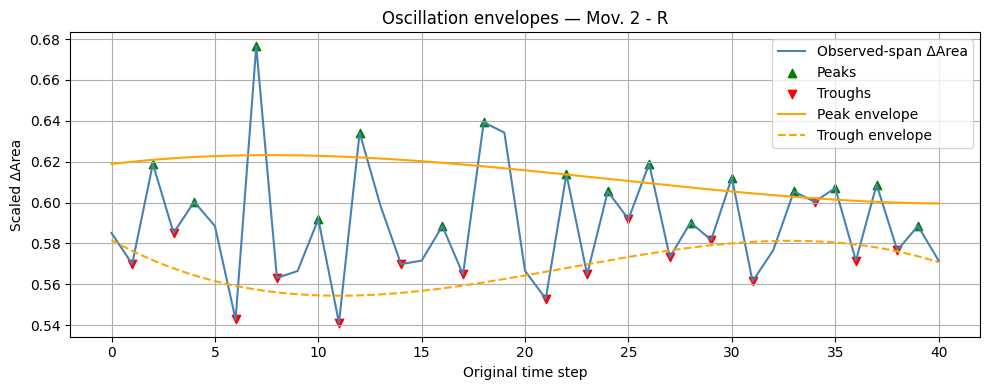

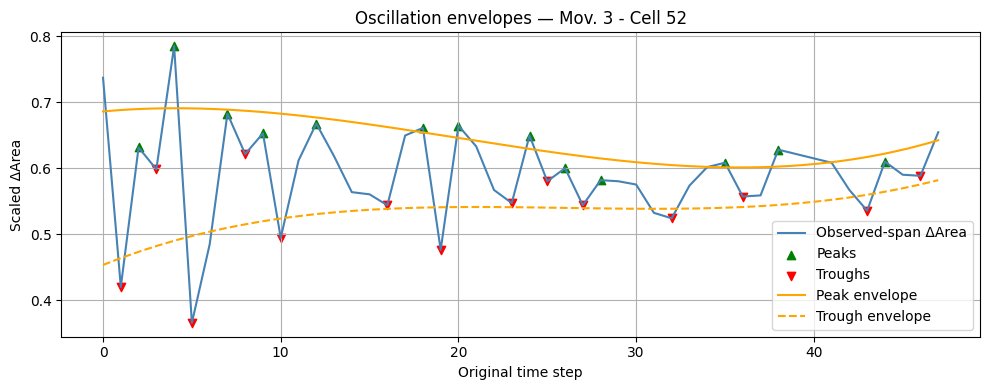

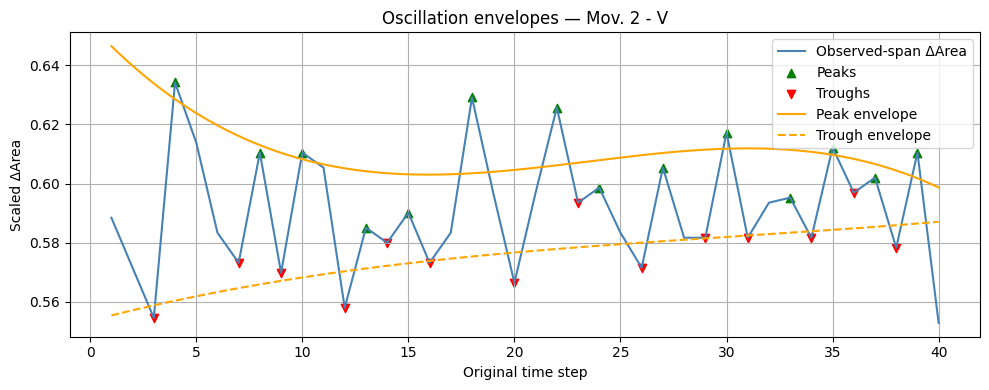

In [13]:
import matplotlib.pyplot as plt
import random
from scipy.signal import find_peaks

random.seed(0)
for cell_id in random.sample(list(df_wide_delta_copy.columns), 3):
    observed, observed_time = prepare_observed_span(df_wide_delta_copy[cell_id].to_numpy())
    peaks, _ = find_peaks(observed)
    troughs, _ = find_peaks(-observed)
    x_dense = np.linspace(observed_time[0], observed_time[-1], 300)
    coeffs_peak = df_magnitude_features.loc[cell_id, ['poly_peak_c0','poly_peak_c1','poly_peak_c2','poly_peak_c3']].to_numpy(dtype=float)
    coeffs_trough = df_magnitude_features.loc[cell_id, ['poly_trough_c0','poly_trough_c1','poly_trough_c2','poly_trough_c3']].to_numpy(dtype=float)
    def eval_poly(c, x): return c[0] + c[1]*x + c[2]*x**2 + c[3]*x**3
    plt.figure(figsize=(10, 4))
    plt.plot(observed_time, observed, color='steelblue', label='Observed-span ΔArea')
    plt.scatter(observed_time[peaks], observed[peaks], color='green', marker='^', label='Peaks')
    plt.scatter(observed_time[troughs], observed[troughs], color='red', marker='v', label='Troughs')
    if not np.isnan(coeffs_peak).any(): plt.plot(x_dense, eval_poly(coeffs_peak, x_dense), color='orange', label='Peak envelope')
    if not np.isnan(coeffs_trough).any(): plt.plot(x_dense, eval_poly(coeffs_trough, x_dense), color='orange', linestyle='--', label='Trough envelope')
    plt.title(f'Oscillation envelopes — {cell_id}')
    plt.xlabel('Original time step'); plt.ylabel('Scaled ΔArea'); plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()


### e. Complexity and Autocorrelation Features (`df_complexity_features`)

Autocorrelation, sample entropy, and Hurst exponent are calculated over each cell's observed span. `sample_entropy` is retained diagnostically but remains excluded from export because it is non-finite for a substantial subset of cells.


In [14]:
def hurst_rs(series):
    """Estimate Hurst exponent using rescaled range (R/S) method."""
    N = len(series)
    if N < 20:
        return np.nan

    mean = np.mean(series)
    Y = np.cumsum(series - mean)
    R = np.max(Y) - np.min(Y)
    S = np.std(series)
    
    if S == 0:
        return np.nan
    
    return np.log(R / S) / np.log(N)


In [15]:
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import acf
import antropy as ant

complexity_features = []
lags_to_check = list(range(2, 11))
for series in delta_series:
    observed, observed_time = prepare_observed_span(series)
    if len(observed) < 10:
        complexity_features.append({'autocorr_lag1': np.nan, 'autocorr_lagk': np.nan, 'sample_entropy': np.nan, 'hurst_exponent': np.nan})
        continue
    autocorrs = acf(observed, nlags=max(lags_to_check), fft=False)
    try: sampen = ant.sample_entropy(observed)
    except Exception: sampen = np.nan
    try: hurst = hurst_rs(observed)
    except Exception: hurst = np.nan
    complexity_features.append({
        'autocorr_lag1': autocorrs[1],
        'autocorr_lagk': np.max([autocorrs[lag] for lag in lags_to_check]),
        'sample_entropy': sampen,
        'hurst_exponent': hurst
    })

df_complexity_features = pd.DataFrame(complexity_features, index=df_wide_delta_copy.columns)
display(df_complexity_features.info())
display(df_complexity_features.head())


<class 'pandas.core.frame.DataFrame'>
Index: 108 entries, Mov. 1 - Cell 10 to Mov. 3 - Cell 9
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   autocorr_lag1   108 non-null    float64
 1   autocorr_lagk   108 non-null    float64
 2   sample_entropy  108 non-null    float64
 3   hurst_exponent  108 non-null    float64
dtypes: float64(4)
memory usage: 8.3+ KB


None

,autocorr_lag1,autocorr_lagk,sample_entropy,hurst_exponent
Mov. 1 - Cell 10,-0.267247,0.299287,1.791759,0.298541
Mov. 1 - Cell 10.1,-0.104398,0.081871,1.673976,0.373219
Mov. 1 - Cell 11,-0.187388,0.176169,1.945910,0.481075
Mov. 1 - Cell 11.1,-0.399299,0.198061,0.916291,0.452267
Mov. 1 - Cell 12,-0.672669,0.307218,1.386294,0.415076


### f. Early vs. Late Behavior Features (`df_early_late_features`)

Early and late are cell-relative: the first 10 and last 10 observations within each cell's observed span. Missing padded endpoints are not part of either window. Existing mean, standard-deviation, lag-1 autocorrelation, and delta-mean definitions are preserved.


In [16]:
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import acf

window_size = 10
early_late_features = []
for series in delta_series:
    observed, observed_time = prepare_observed_span(series)
    if len(observed) < 2 * window_size:
        early_late_features.append({name: np.nan for name in ['early_mean','late_mean','early_std','late_std','early_autocorr','late_autocorr','delta_mean']})
        continue
    early, late = observed[:window_size], observed[-window_size:]
    def lag1_autocorr(segment):
        if len(segment) < 2 or np.std(segment) == 0: return 0.0
        try:
            values = acf(segment, nlags=1, fft=False)
            return values[1] if len(values) > 1 else 0.0
        except Exception: return 0.0
    early_late_features.append({
        'early_mean': np.mean(early), 'late_mean': np.mean(late),
        'early_std': np.std(early), 'late_std': np.std(late),
        'early_autocorr': lag1_autocorr(early), 'late_autocorr': lag1_autocorr(late),
        'delta_mean': np.mean(late) - np.mean(early)
    })

df_early_late_features = pd.DataFrame(early_late_features, index=df_wide_delta_copy.columns)
display(df_early_late_features.info())
display(df_early_late_features.head())


<class 'pandas.core.frame.DataFrame'>
Index: 108 entries, Mov. 1 - Cell 10 to Mov. 3 - Cell 9
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   early_mean      108 non-null    float64
 1   late_mean       108 non-null    float64
 2   early_std       108 non-null    float64
 3   late_std        108 non-null    float64
 4   early_autocorr  108 non-null    float64
 5   late_autocorr   108 non-null    float64
 6   delta_mean      108 non-null    float64
dtypes: float64(7)
memory usage: 10.8+ KB


None

,early_mean,late_mean,early_std,late_std,early_autocorr,late_autocorr,delta_mean
Mov. 1 - Cell 10,0.583736,0.587462,0.028254,0.022329,-0.432464,-0.316137,0.003726
Mov. 1 - Cell 10.1,0.594020,0.592373,0.037879,0.039961,-0.224302,0.148243,-0.001647
Mov. 1 - Cell 11,0.588986,0.590510,0.035508,0.020696,-0.105980,-0.249496,0.001524
Mov. 1 - Cell 11.1,0.594629,0.592373,0.041028,0.071260,-0.244820,-0.411757,-0.002256
Mov. 1 - Cell 12,0.587123,0.591526,0.044341,0.017284,-0.638457,-0.686686,0.004403


### g. Oscillation Shape Features (`df_shape_features`)

Asymmetry and sharpness are computed on each observed span. The former `energy = sum(series**2)` feature was removed because it strongly encoded observed trajectory length; no replacement feature is introduced.


In [17]:
import numpy as np
import pandas as pd
from scipy.signal import find_peaks

shape_features = []
for series in delta_series:
    observed, observed_time = prepare_observed_span(series)
    if len(observed) < 5:
        shape_features.append({'asymmetry_index': np.nan, 'sharpness_index': np.nan})
        continue
    peaks, _ = find_peaks(observed)
    troughs, _ = find_peaks(-observed)
    extrema = sorted([(i, 'peak') for i in peaks] + [(i, 'trough') for i in troughs])
    rise_durations, fall_durations = [], []
    for (idx1, type1), (idx2, type2) in zip(extrema, extrema[1:]):
        duration = observed_time[idx2] - observed_time[idx1]
        if type1 == 'trough' and type2 == 'peak': rise_durations.append(duration)
        elif type1 == 'peak' and type2 == 'trough': fall_durations.append(duration)
    asymmetry = np.mean(rise_durations) / np.mean(fall_durations) if rise_durations and fall_durations else np.nan
    diffs = np.abs(np.diff(observed))
    shape_features.append({'asymmetry_index': asymmetry, 'sharpness_index': np.max(diffs) if len(diffs) else np.nan})

df_shape_features = pd.DataFrame(shape_features, index=df_wide_delta_copy.columns)
display(df_shape_features.info())
display(df_shape_features.head())


<class 'pandas.core.frame.DataFrame'>
Index: 108 entries, Mov. 1 - Cell 10 to Mov. 3 - Cell 9
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   asymmetry_index  108 non-null    float64
 1   sharpness_index  108 non-null    float64
dtypes: float64(2)
memory usage: 6.6+ KB


None

,asymmetry_index,sharpness_index
Mov. 1 - Cell 10,0.944444,0.106688
Mov. 1 - Cell 10.1,0.789474,0.123388
Mov. 1 - Cell 11,0.941176,0.127016
Mov. 1 - Cell 11.1,0.944444,0.265879
Mov. 1 - Cell 12,0.773810,0.169350


### Feature Storage and Organization

Each category of features is stored in its own `pandas.DataFrame`, where:

- **Rows** correspond to individual Drosophila cells (e.g., `"Mov. 3 - Cell 1"`)
- **Columns** correspond to engineered features specific to that category

For example:
- `df_stat_summary` contains statistical summary features like mean, standard deviation, and skewness.
- `df_peak_timing_features` contains timing and rhythm-related descriptors.
- All other categories (`b`–`g`) follow the same structure.

#### Combined Feature Frame: `df_all_features`

The production workflow generates 56 Category a–g columns; `energy` is not included. Non-finite values are reported explicitly, and `sample_entropy` is removed before export because it is non-finite for a substantial subset of cells. The validated production candidate matrix therefore contains 55 usable features.


#### Example Structure

| a       | a       | b                | ... | g                |
|---------|---------|------------------|-----|------------------|
| mean    | std     | dominant_freq    | ... | sharpness_index  |
| 0.523   | 0.112   | 0.042            | ... | 0.087            |
| 0.497   | 0.093   | 0.038            | ... | 0.103            |

This multi-indexed feature frame (`df_all_features`) supports:
- **Dimensionality reduction** by PCA and NMF;
- **Ward and KMeans clustering** of those production representations; and
- **Feature pruning and consensus-group characterization**.

The original Drosophila cell identifiers are retained as the DataFrame index throughout the pipeline.


In [18]:
# Step 1: Map categories to their DataFrames
feature_frames = {
    'a': df_stat_summary,
    'b': df_oscillation_features,
    'c': df_peak_timing_features,
    'd': df_magnitude_features,
    'e': df_complexity_features,
    'f': df_early_late_features,
    'g': df_shape_features,
}

# Step 2: Build multi-indexed columns
multi_indexed_features = []

for category, df in feature_frames.items():
    df_copy = df.copy()
    df_copy.columns = pd.MultiIndex.from_product([[category], df.columns])
    multi_indexed_features.append(df_copy)

# Step 3: Concatenate all along columns
df_all_features = pd.concat(multi_indexed_features, axis=1)

# Step 4: Sanity check
display(df_all_features.info())
display(df_all_features.head())


<class 'pandas.core.frame.DataFrame'>
Index: 108 entries, Mov. 1 - Cell 10 to Mov. 3 - Cell 9
Data columns (total 56 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   (a, mean)                              108 non-null    float64
 1   (a, std)                               108 non-null    float64
 2   (a, range)                             108 non-null    float64
 3   (a, median)                            108 non-null    float64
 4   (a, skew)                              108 non-null    float64
 5   (a, kurtosis)                          108 non-null    float64
 6   (b, dominant_freq)                     108 non-null    float64
 7   (b, total_power)                       108 non-null    float64
 8   (b, band_power_low)                    108 non-null    float64
 9   (b, band_power_mid)                    108 non-null    float64
 10  (b, band_power_high)                   108 non-null 

None

a                                          \
                        mean       std     range    median      skew   
Mov. 1 - Cell 10    0.587676  0.023740  0.121932  0.588479  0.091052   
Mov. 1 - Cell 10.1  0.592527  0.031883  0.166268  0.586206  0.737495   
Mov. 1 - Cell 11    0.589191  0.025852  0.127016  0.586784  0.951941   
Mov. 1 - Cell 11.1  0.593495  0.045360  0.265879  0.586087  1.112811   
Mov. 1 - Cell 12    0.589701  0.027997  0.169350  0.593559 -0.412399   

                                         b                             \
                    kurtosis dominant_freq total_power band_power_low   
Mov. 1 - Cell 10    1.233599      1.026316    0.000564   6.914142e-34   
Mov. 1 - Cell 10.1  1.382178      0.631579    0.001017   1.442580e-33   
Mov. 1 - Cell 11    1.490865      0.789474    0.000668   8.740841e-33   
Mov. 1 - Cell 11.1  3.386564      1.263158    0.002057   5.334986e-35   
Mov. 1 - Cell 12    2.607295      1.500000    0.000784   5.252320e-33   

                                   ...              e          f            \
                   band_power_mid  ... hurst_exponent early_mean late_mean   
Mov. 1 - Cell 10     1.102492e-07  ...       0.298541   0.583736  0.587462   
Mov. 1 - Cell 10.1   4.274636e-06  ...       0.373219   0.594020  0.592373   
Mov. 1 - Cell 11     2.991022e-06  ...       0.481075   0.588986  0.590510   
Mov. 1 - Cell 11.1   1.947201e-05  ...       0.452267   0.594629  0.592373   
Mov. 1 - Cell 12     4.604827e-06  ...       0.415076   0.587123  0.591526   

                                                                     \
                   early_std  late_std early_autocorr late_autocorr   
Mov. 1 - Cell 10    0.028254  0.022329      -0.432464     -0.316137   
Mov. 1 - Cell 10.1  0.037879  0.039961      -0.224302      0.148243   
Mov. 1 - Cell 11    0.035508  0.020696      -0.105980     -0.249496   
Mov. 1 - Cell 11.1  0.041028  0.071260      -0.244820     -0.411757   
Mov. 1 - Cell 12    0.044341  0.017284      -0.638457     -0.686686   

                                            g                  
                   delta_mean asymmetry_index sharpness_index  
Mov. 1 - Cell 10     0.003726        0.944444        0.106688  
Mov. 1 - Cell 10.1  -0.001647        0.789474        0.123388  
Mov. 1 - Cell 11     0.001524        0.941176        0.127016  
Mov. 1 - Cell 11.1  -0.002256        0.944444        0.265879  
Mov. 1 - Cell 12     0.004403        0.773810        0.169350  

[5 rows x 56 columns]

#### Export to CSV

In [19]:
df_flat_initial = df_all_features.copy()
df_flat_initial.columns = [f"{cat}_{feat}" for cat, feat in df_flat_initial.columns]
initial_feature_count = df_flat_initial.shape[1]
numeric_values = df_flat_initial.to_numpy(dtype=float)
nonfinite_counts = pd.Series((~np.isfinite(numeric_values)).sum(axis=0), index=df_flat_initial.columns)
nonfinite_counts = nonfinite_counts[nonfinite_counts > 0].sort_values(ascending=False)

print(f"Initial corrected feature count: {initial_feature_count}")
print("Columns containing non-finite values and counts:")
print(nonfinite_counts.to_dict())


Initial corrected feature count: 56
Columns containing non-finite values and counts:
{'e_sample_entropy': 25}


In [20]:
# sample_entropy remains documented diagnostically but is never part of the usable export.
sample_entropy_column = "e_sample_entropy"
if sample_entropy_column not in df_flat_initial.columns:
    raise AssertionError("Expected diagnostic sample_entropy column was not generated")

unexpected_nonfinite = nonfinite_counts.drop(labels=[sample_entropy_column], errors="ignore")
if not unexpected_nonfinite.empty:
    raise ValueError(f"Unexpected non-finite feature columns: {unexpected_nonfinite.to_dict()}")

df_flat = df_flat_initial.drop(columns=[sample_entropy_column])
final_feature_count = df_flat.shape[1]
print(f"Removed unusable feature: {sample_entropy_column}")
print(f"Final usable feature count: {final_feature_count}")


Removed unusable feature: e_sample_entropy
Final usable feature count: 55


In [21]:
assert "g_energy" not in df_flat_initial.columns and "g_energy" not in df_flat.columns
assert len(df_flat) == len(df_wide_delta_copy.columns)
assert df_flat.index.equals(df_wide_delta_copy.columns)
assert np.isfinite(df_flat.to_numpy(dtype=float)).all()

print("energy absent: True")
print(f"One feature row per retained cell: {len(df_flat)} rows for {len(df_wide_delta_copy.columns)} cells")
display(df_flat.info())
display(df_flat.head())


energy absent: True
One feature row per retained cell: 108 rows for 108 cells
<class 'pandas.core.frame.DataFrame'>
Index: 108 entries, Mov. 1 - Cell 10 to Mov. 3 - Cell 9
Data columns (total 55 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   a_mean                              108 non-null    float64
 1   a_std                               108 non-null    float64
 2   a_range                             108 non-null    float64
 3   a_median                            108 non-null    float64
 4   a_skew                              108 non-null    float64
 5   a_kurtosis                          108 non-null    float64
 6   b_dominant_freq                     108 non-null    float64
 7   b_total_power                       108 non-null    float64
 8   b_band_power_low                    108 non-null    float64
 9   b_band_power_mid                    108 non-null    float64
 10  b_band_pow

None

,a_mean,a_std,a_range,a_median,a_skew,a_kurtosis,b_dominant_freq,b_total_power,b_band_power_low,b_band_power_mid,...,e_hurst_exponent,f_early_mean,f_late_mean,f_early_std,f_late_std,f_early_autocorr,f_late_autocorr,f_delta_mean,g_asymmetry_index,g_sharpness_index
Mov. 1 - Cell 10,0.587676,0.023740,0.121932,0.588479,0.091052,1.233599,1.026316,0.000564,6.914142e-34,1.102492e-07,...,0.298541,0.583736,0.587462,0.028254,0.022329,-0.432464,-0.316137,0.003726,0.944444,0.106688
Mov. 1 - Cell 10.1,0.592527,0.031883,0.166268,0.586206,0.737495,1.382178,0.631579,0.001017,1.442580e-33,4.274636e-06,...,0.373219,0.594020,0.592373,0.037879,0.039961,-0.224302,0.148243,-0.001647,0.789474,0.123388
Mov. 1 - Cell 11,0.589191,0.025852,0.127016,0.586784,0.951941,1.490865,0.789474,0.000668,8.740841e-33,2.991022e-06,...,0.481075,0.588986,0.590510,0.035508,0.020696,-0.105980,-0.249496,0.001524,0.941176,0.127016
Mov. 1 - Cell 11.1,0.593495,0.045360,0.265879,0.586087,1.112811,3.386564,1.263158,0.002057,5.334986e-35,1.947201e-05,...,0.452267,0.594629,0.592373,0.041028,0.071260,-0.244820,-0.411757,-0.002256,0.944444,0.265879
Mov. 1 - Cell 12,0.589701,0.027997,0.169350,0.593559,-0.412399,2.607295,1.500000,0.000784,5.252320e-33,4.604827e-06,...,0.415076,0.587123,0.591526,0.044341,0.017284,-0.638457,-0.686686,0.004403,0.773810,0.169350


In [22]:
FEATURE_OUTPUT = PROCESSED_DIR / "drosophila_features.csv"
df_flat.to_csv(FEATURE_OUTPUT)
print(f"Corrected feature CSV: {FEATURE_OUTPUT}")


Corrected feature CSV: data\processed\drosophila_features.csv


In [23]:
from sklearn.preprocessing import MinMaxScaler

minmax = MinMaxScaler()
df_scaled_01 = pd.DataFrame(minmax.fit_transform(df_flat), index=df_flat.index, columns=df_flat.columns)
SCALED_FEATURE_OUTPUT = PROCESSED_DIR / "drosophila_features_scaled.csv"
df_scaled_01.to_csv(SCALED_FEATURE_OUTPUT)
print(f"Scaled feature CSV: {SCALED_FEATURE_OUTPUT}")


Scaled feature CSV: data\processed\drosophila_features_scaled.csv


#### Build and save feature dictionary

In [24]:
import pandas as pd

# Load feature CSV and get feature names
features_df = pd.read_csv(FEATURE_OUTPUT)
feature_columns = features_df.columns.drop("Unnamed: 0").tolist()

# Storage for feature metadata
feature_dict = []

# Define helper to add entries from each category
def add_entries(prefix, entries, category):
    for var, (label, desc) in entries.items():
        full_name = f"{prefix}_{var}"
        if full_name in feature_columns:
            feature_dict.append({
                "Feature_Name": full_name,
                "Feature_Label": label,
                "Feature_Description": desc,
                "Feature_Category": category
            })

# Define each category
a = {
    "mean": ("Mean of delta", "Average of all non-NaN delta values"),
    "std": ("Standard deviation", "Variability of delta values"),
    "range": ("Range", "Difference between max and min delta values"),
    "median": ("Median", "Middle value of the delta distribution"),
    "skew": ("Skewness", "Asymmetry of the delta distribution"),
    "kurtosis": ("Kurtosis", "Peakedness or tail heaviness of the delta distribution")
}
b = {
    "dominant_freq": ("Dominant frequency", "Highest-power frequency in cycles/hour"),
    "total_power": ("Total spectral power", "PSD integrated over frequency"),
    "band_power_low": ("Low-frequency band power", "Power in a defined low-frequency band"),
    "band_power_mid": ("Mid-frequency band power", "Power in a mid-frequency band"),
    "band_power_high": ("High-frequency band power", "Power in a high-frequency band"),
    "spectral_entropy": ("Normalized spectral entropy", "Length-normalized entropy of the PSD distribution"),
    "spectral_flatness": ("Spectral flatness", "Flatness of the frequency distribution")
}
c = {
    "avg_time_between_peaks": ("Average time between peaks", "Mean time steps between maxima"),
    "std_time_between_peaks": ("Std dev of time between peaks", "Variation in peak spacing"),
    "avg_time_between_troughs": ("Average time between troughs", "Mean time steps between minima"),
    "std_time_between_troughs": ("Std dev of time between troughs", "Variation in trough spacing"),
    "mean_peak_to_trough_time": ("Mean fall time", "Time from peak to next trough"),
    "mean_trough_to_peak_time": ("Mean rise time", "Time from trough to next peak"),
    "oscillation_rate": ("Oscillation rate", "Total peaks+troughs per time step")
}
d = {
    "slope_magnitude": ("Slope of oscillation magnitude", "Linear trend of amplitude"),
    
    "poly_mag_c0": ("Magnitude poly fit (c0)", "Polynomial fit to magnitude: coefficient c0"),
    "poly_mag_c1": ("Magnitude poly fit (c1)", "Polynomial fit to magnitude: coefficient c1"),
    "poly_mag_c2": ("Magnitude poly fit (c2)", "Polynomial fit to magnitude: coefficient c2"),
    "poly_mag_c3": ("Magnitude poly fit (c3)", "Polynomial fit to magnitude: coefficient c3"),
    
    "poly_peak_c0": ("Peak magnitude poly fit (c0)", "Polynomial fit to peak magnitude: coefficient c0"),
    "poly_peak_c1": ("Peak magnitude poly fit (c1)", "Polynomial fit to peak magnitude: coefficient c1"),
    "poly_peak_c2": ("Peak magnitude poly fit (c2)", "Polynomial fit to peak magnitude: coefficient c2"),
    "poly_peak_c3": ("Peak magnitude poly fit (c3)", "Polynomial fit to peak magnitude: coefficient c3"),

    "poly_trough_c0": ("Trough magnitude poly fit (c0)", "Polynomial fit to trough magnitude: coefficient c0"),
    "poly_trough_c1": ("Trough magnitude poly fit (c1)", "Polynomial fit to trough magnitude: coefficient c1"),
    "poly_trough_c2": ("Trough magnitude poly fit (c2)", "Polynomial fit to trough magnitude: coefficient c2"),
    "poly_trough_c3": ("Trough magnitude poly fit (c3)", "Polynomial fit to trough magnitude: coefficient c3"),

    "mean_magnitude": ("Mean amplitude", "Average oscillation magnitude"),
    "std_magnitude": ("Std dev of amplitude", "Variation in oscillation amplitude"),
    "initial_magnitude": ("Initial oscillation strength", "Average magnitude in first 2–3 cycles"),
    "final_magnitude": ("Final oscillation strength", "Average magnitude in last 2–3 cycles"),
    
    "mean_peak_to_trough_magnitude": ("Mean fall amplitude", "Average drop from peak to trough"),
    "mean_trough_to_peak_magnitude": ("Mean rise amplitude", "Average rise from trough to peak"),
    
    "initial_peak_to_trough_magnitude": ("Initial fall amplitude", "Fall magnitude in first 2–3 cycles"),
    "final_peak_to_trough_magnitude": ("Final fall amplitude", "Fall magnitude in last 2–3 cycles"),
    
    "initial_trough_to_peak_magnitude": ("Initial rise amplitude", "Rise magnitude in first 2–3 cycles"),
    "final_trough_to_peak_magnitude": ("Final rise amplitude", "Rise magnitude in last 2–3 cycles")
}

e = {
    "autocorr_lag1": ("Autocorrelation (lag 1)", "Correlation with lag-1"),
    "autocorr_lagk": ("Max autocorrelation (lags 2–10)", "Strongest long-lag autocorr"),
    "hurst_exponent": ("Hurst exponent", "Trend or reversal tendency")
}
f = {
    "early_mean": ("Early mean", "Mean in early window"),
    "late_mean": ("Late mean", "Mean in late window"),
    "early_std": ("Early standard deviation", "Std dev in early window"),
    "late_std": ("Late standard deviation", "Std dev in late window"),
    "early_autocorr": ("Early autocorrelation", "Lag-1 autocorr (early)"),
    "late_autocorr": ("Late autocorrelation", "Lag-1 autocorr (late)"),
    "delta_mean": ("Change in mean", "Late mean - early mean")
}
g = {
    "asymmetry_index": ("Asymmetry index", "Ratio of rise/fall time"),
    "sharpness_index": ("Sharpness index", "Steepest slope"),
}

# Add features by category
add_entries("a", a, "Statistical Summary")
add_entries("b", b, "Oscillation")
add_entries("c", c, "Peak & Trough Timing")
add_entries("d", d, "Magnitude Change")
add_entries("e", e, "Complexity & Autocorrelation")
add_entries("f", f, "Early vs. Late Behavior")
add_entries("g", g, "Oscillation Shape")

# Create dataframe and save
feature_dict_df = pd.DataFrame(feature_dict)
feature_dict_df.to_csv(PROCESSED_DIR / "feature_dictionary.csv", index=False)

# Display the first few rows
feature_dict_df.head()


,Feature_Name,Feature_Label,Feature_Description,Feature_Category
0,a_mean,Mean of delta,Average of all non-NaN delta values,Statistical Summary
1,a_std,Standard deviation,Variability of delta values,Statistical Summary
2,a_range,Range,Difference between max and min delta values,Statistical Summary
3,a_median,Median,Middle value of the delta distribution,Statistical Summary
4,a_skew,Skewness,Asymmetry of the delta distribution,Statistical Summary
